# QNN

### Content   <a name="content"></a>

1. [Set a "seed" for all the libraries involved in the randomness](#1)
2. [Upload the datasets](#2)
3. [Create the QNN dataset ](#3)
4. [QNN](#4)
5. [Training loop](#5)
6. [Validation](#6)
7. [Evaluation](#7)

## Set a "seed" for all the libraries involved in the randomness <a name="1"></a>

In [1]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    # Set seed for Python's random module
    random.seed(seed)
    
    # Set seed for NumPy
    np.random.seed(seed)
    
    # Set seed for PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # If using multi-GPU
    
    # Ensure deterministic operations in PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Run this once at the start of your notebook
set_seed(42)

[<a href="#content">Back to top</a>]

## Upload the datasets <a name="2"></a>

In [2]:
import numpy as np
import json

import warnings

# To stop PennyLane warning that it has officially moved on to the NumPy 2.0 era
# and will soon stop supporting the version you just installed (1.26.4).
warnings.filterwarnings("ignore", category=UserWarning, module="pennylane")

def extract_molecule_coords(json_file_path):
    with open(json_file_path, 'r') as f:
        data = json.load(f)
    
    compounds = data.get("PC_Compounds", [])
    all_molecules_coords = []
    
    for compound in compounds:
        cid = compound.get("id", {}).get("id", {}).get("cid")
        # Accessing the first conformer in the coords list
        coords_list = compound.get("coords", [])
        
        if coords_list:
            # Usually conformers[0] contains the primary coordinate data
            conformers = coords_list[0].get("conformers", [])
            if conformers:
                conf = conformers[0]
                x = conf.get("x", [])
                y = conf.get("y", [])
                z = conf.get("z", [])
                
                # Zip the lists to get (x, y, z) tuples for each atom
                atom_coords = list(zip(x, y, z))
                all_molecules_coords.append({"cid": cid, "coords": atom_coords})
                
    return all_molecules_coords

# Usage
file_path = r'C:/Users/ivano/OneDrive/Self-appeared/Documents/GitHubMalariaII/PubChem_atomic_coordinates.json'
molecules = extract_molecule_coords(file_path)

# Example: Print coordinates of the first molecule
if molecules:
    print(f"CID: {molecules[0]['cid']}")
    print(f"First 3 atoms (x, y, z): {molecules[0]['coords'][:]}")

CID: 4169706
First 3 atoms (x, y, z): [(-5.3478, -0.4125, 0.2101), (0.1263, -0.8698, -0.0819), (-1.5262, 2.8752, -0.3541), (0.8602, 0.2885, 0.3448), (0.4523, 1.5224, -0.4579), (2.3391, 0.002, 0.1907), (-1.0248, 1.7598, -0.2787), (-1.8538, 0.5538, -0.0773), (-1.232, -0.6966, -0.0131), (2.7851, -0.8297, -0.8362), (3.2547, 0.5701, 1.0762), (-3.2447, 0.6554, 0.0038), (-2.0071, -1.8517, 0.0978), (-4.0132, -0.5018, 0.135), (-3.3965, -1.7528, 0.1768), (4.1476, -1.0933, -0.9779), (4.617, 0.3063, 0.9346), (5.0638, -0.5252, -0.0926), (0.6474, 0.4344, 1.4143), (0.9974, 2.406, -0.1078), (0.6403, 1.3915, -1.5301), (2.094, -1.2741, -1.5472), (2.9193, 1.2211, 1.879), (-3.7454, 1.6182, -0.0441), (-1.5364, -2.8306, 0.1336), (-3.9996, -2.651, 0.2714), (4.4957, -1.7383, -1.7794), (5.3303, 0.7492, 1.6235), (6.1246, -0.7296, -0.2035)]


In [3]:
type(molecules)

list

In [4]:
import pandas as pd 

# df_molecules = pd.DataFrame(molecules, columns=['X', 'Y', 'Z'])
df_molecules = pd.DataFrame(molecules)

df_molecules.head()

,cid,coords
0,4169706,"[(-5.3478, -0.4125, 0.2101), (0.1263, -0.8698,..."
1,13076,"[(-1.2252, -0.706, 0), (-1.2252, 0.7061, -0.00..."
2,23885521,"[(-1.2567, 0.535, 1.4587), (-3.3824, -1.7902, ..."
3,588066,"[(-0.9931, -1.1739, 1.7388), (1.6043, 2.1302, ..."
4,16018404,"[(6.2467, 2.9357, -0.3819), (-0.0568, -1.4191,..."


In [5]:
df_molecules = df_molecules.rename(columns={'cid': 'CID'})

[<a href="#content">Back to top</a>]

In [6]:
import pandas as pd
from torch_geometric.data import Data

# 1. Load the CSV file
csv_path = 'AID499704_CIDs_SIDs_SMILESs_targets.csv' 
df = pd.read_csv(csv_path)

df.head()

,CID,SID,SMILES,target
0,4169706,103712074,C1C(OC2=C(C1=O)C=C(C=C2)F)C3=CC=CC=C3,0
1,13076,103713284,CC1=C2C=CC=CC2=C(C3=CC=CC=C13)C,1
2,23885521,103713805,CC1=CC=CC=C1N(CC(=O)NCC2CCCO2)C(=O)C3=C(C(=NS3...,0
3,588066,103711416,CN1C2=C(C(=O)N(C1=O)C)N(C=N2)CC(CNC3=NCCCC3)O,0
4,16018404,103712702,COC1=CC=CC(=C1)C2=NOC(=C2)C(=O)NC3=C(C=CC(=C3)...,1


In [7]:
df_merged = pd.merge(df_molecules, df, on='CID')

print(df_merged.shape)
df_merged.head()

(1933, 5)


,CID,coords,SID,SMILES,target
0,4169706,"[(-5.3478, -0.4125, 0.2101), (0.1263, -0.8698,...",103712074,C1C(OC2=C(C1=O)C=C(C=C2)F)C3=CC=CC=C3,0
1,13076,"[(-1.2252, -0.706, 0), (-1.2252, 0.7061, -0.00...",103713284,CC1=C2C=CC=CC2=C(C3=CC=CC=C13)C,1
2,23885521,"[(-1.2567, 0.535, 1.4587), (-3.3824, -1.7902, ...",103713805,CC1=CC=CC=C1N(CC(=O)NCC2CCCO2)C(=O)C3=C(C(=NS3...,0
3,588066,"[(-0.9931, -1.1739, 1.7388), (1.6043, 2.1302, ...",103711416,CN1C2=C(C(=O)N(C1=O)C)N(C=N2)CC(CNC3=NCCCC3)O,0
4,16018404,"[(6.2467, 2.9357, -0.3819), (-0.0568, -1.4191,...",103712702,COC1=CC=CC(=C1)C2=NOC(=C2)C(=O)NC3=C(C=CC(=C3)...,1


In [8]:
df = df_merged[['coords', 'target']]
print(df.shape)
df.head()

(1933, 2)


,coords,target
0,"[(-5.3478, -0.4125, 0.2101), (0.1263, -0.8698,...",0
1,"[(-1.2252, -0.706, 0), (-1.2252, 0.7061, -0.00...",1
2,"[(-1.2567, 0.535, 1.4587), (-3.3824, -1.7902, ...",0
3,"[(-0.9931, -1.1739, 1.7388), (1.6043, 2.1302, ...",0
4,"[(6.2467, 2.9357, -0.3819), (-0.0568, -1.4191,...",1


In [9]:
# Run this cell to check your balance
class_balance = df['target'].value_counts(normalize=True)
print(f"Class Distribution:\n{class_balance}")

Class Distribution:
target
1    0.513192
0    0.486808
Name: proportion, dtype: float64


In [10]:
import numpy as np
import torch
import ast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

def prepare_qnn_data_three_way(df, batch_size=32):
    # 1. Extreme Failsafe: Flatten and Pad
    def flatten(item):
        if isinstance(item, (list, tuple, np.ndarray)):
            return [x for sub in item for x in flatten(sub)]
        return [float(item)]

    # Clean the coords column
    clean_coords = [flatten(x) for x in df['coords']]
    max_len = max(len(x) for x in clean_coords)
    
    # Pad sequences to max_len
    padded_coords = [x + [0.0] * (max_len - len(x)) for x in clean_coords]
    coords_array = np.array(padded_coords, dtype=float)
    targets = df['target'].values
    
    # 2. Sequential Splitting
    # First split: Train (80%) and Temp (20%)
    train_idx, temp_idx = train_test_split(range(len(df)), test_size=0.2, random_state=42)
    # Second split: Validation (10%) and Test (10%)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)
    
    # 3. Scaling (IMPORTANT: Fit ONLY on train)
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    
    # Prepare datasets
    def create_dataset(indices, is_train=False):
        if is_train:
            coords_scaled = scaler.fit_transform(coords_array[indices])
        else:
            coords_scaled = scaler.transform(coords_array[indices])
            
        return [
            Data(x=torch.tensor(x, dtype=torch.float32).unsqueeze(0), 
                 y=torch.tensor(y, dtype=torch.long)) 
            for x, y in zip(coords_scaled, targets[indices])
        ]

    train_dataset = create_dataset(train_idx, is_train=True)
    val_dataset = create_dataset(val_idx, is_train=False)
    test_dataset = create_dataset(test_idx, is_train=False)
    
    # 4. Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset

# Execution
train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = prepare_qnn_data_three_way(df)

# Validation check
print(f"Data loaders created!")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
batch = next(iter(train_loader))
print(f"Batch data shape: {batch.x.shape} (Expected: [batch_size, padded_length])")

Data loaders created!
Train: 1546 | Val: 193 | Test: 194
Batch data shape: torch.Size([32, 270]) (Expected: [batch_size, padded_length])


[<a href="#content">Back to top</a>]

## QNN <a name="4"></a>

In [11]:
import torch
import pennylane as qml
from torch_geometric.nn import global_mean_pool

class QNNLayer(torch.nn.Module):
    def __init__(self, n_qubits, n_layers=6, input_dim=270): 
        super(QNNLayer, self).__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        # 1. Feature Projection
        self.feature_projection = torch.nn.Linear(input_dim, n_qubits)
        
        # 2. Setup Quantum components
        self.dev = qml.device("default.qubit", wires=n_qubits)
        self.qnode = qml.QNode(self._circuit, self.dev, interface="torch")
        
        # Use StronglyEntanglingLayers for higher expressivity
        # Structure is (n_layers, n_qubits, 3) for rot angles
        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.qnn = qml.qnn.TorchLayer(self.qnode, weight_shapes)
        
        # 3. Final Readout Layer
        self.final_readout = torch.nn.Linear(n_qubits, 1)

    def _circuit(self, inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(self.n_qubits))
        qml.StronglyEntanglingLayers(weights, wires=range(self.n_qubits))
        return [qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]

    def forward(self, batch):
        # Use simple projection without tanh or ReLU to preserve distribution
        x = self.feature_projection(batch.x) 
        
        # Pass through QNN
        node_outputs = self.qnn(x)
        
        # Pool across graph nodes
        graph_pooled = global_mean_pool(node_outputs, batch.batch)
        
        # Final classification head
        return self.final_readout(graph_pooled)

# Update instantiation
n_qubits = 4
model = QNNLayer(n_qubits=n_qubits, input_dim=270)
# Lower the learning rate for more stable quantum-classical training
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
# Check if the model is trainable
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Layer {name} is trainable.")
    else:
        print(f"Layer {name} is NOT trainable.")

Layer feature_projection.weight is trainable.
Layer feature_projection.bias is trainable.
Layer qnn.weights is trainable.
Layer final_readout.weight is trainable.
Layer final_readout.bias is trainable.


[<a href="#content">Back to top</a>]

## Trainign loop and validation <a name="5"></a>

In [13]:
import torch
import torch.optim as optim
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Imports and Setup (Put this at the top of your notebook)
optimizer = optim.Adam(model.parameters(), lr=0.001) 
criterion = torch.nn.BCEWithLogitsLoss()

# 2. Modular Training Function
def train_one_epoch(loader, model, criterion, optimizer):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    for batch in loader:
        optimizer.zero_grad()
        
        # Forward pass
        output = model(batch).view(-1)
        loss = criterion(output, batch.y.float())
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Collect for accuracy (use sigmoid for probability)
        preds = (torch.sigmoid(output) > 0.5).int().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch.y.cpu().numpy())
        
    return total_loss / len(loader), accuracy_score(all_labels, all_preds)

# 3. Modular Validation Function
def validate(loader, model, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            output = model(batch).view(-1)
            loss = criterion(output, batch.y.float())
            total_loss += loss.item()
            
            preds = (torch.sigmoid(output) > 0.5).int().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch.y.cpu().numpy())
            
    return total_loss / len(loader), accuracy_score(all_labels, all_preds)

# 4. The Main Training Loop (This is where you run everything)
epochs = 50
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = validate(val_loader, model, criterion)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Epoch 05 | Train Loss: 0.6927 Acc: 0.5168 | Val Loss: 0.7029 Acc: 0.4404
Epoch 10 | Train Loss: 0.6961 Acc: 0.5045 | Val Loss: 0.6897 Acc: 0.4767
Epoch 15 | Train Loss: 0.6913 Acc: 0.5634 | Val Loss: 0.6973 Acc: 0.4715
Epoch 20 | Train Loss: 0.6887 Acc: 0.5323 | Val Loss: 0.7109 Acc: 0.4819
Epoch 25 | Train Loss: 0.6969 Acc: 0.4793 | Val Loss: 0.6974 Acc: 0.5389
Epoch 30 | Train Loss: 0.6836 Acc: 0.5550 | Val Loss: 0.6975 Acc: 0.4974
Epoch 35 | Train Loss: 0.6690 Acc: 0.6028 | Val Loss: 0.7269 Acc: 0.5440
Epoch 40 | Train Loss: 0.6857 Acc: 0.5511 | Val Loss: 0.7190 Acc: 0.4974
Epoch 45 | Train Loss: 0.6538 Acc: 0.6184 | Val Loss: 0.7689 Acc: 0.4404
Epoch 50 | Train Loss: 0.6707 Acc: 0.6106 | Val Loss: 0.7434 Acc: 0.4870


[<a href="#content">Back to top</a>]

## Evaluation <a name="7"></a>

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(loader, model):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in loader:
            # Pass the WHOLE batch object to the model.
            # The QNNLayer.forward method handles extracting batch.x internally.
            q_out = model(batch) 
            logits = torch.mean(q_out, dim=1)
            
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch.y.cpu().numpy())
            
    # Calculate metrics
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    
    return acc, prec, rec, f1

# Usage:
acc, prec, rec, f1 = evaluate_model(test_loader, model)
print(f"Test Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

Test Accuracy: 0.4691 | Precision: 0.4380 | Recall: 0.6023 | F1-Score: 0.5072


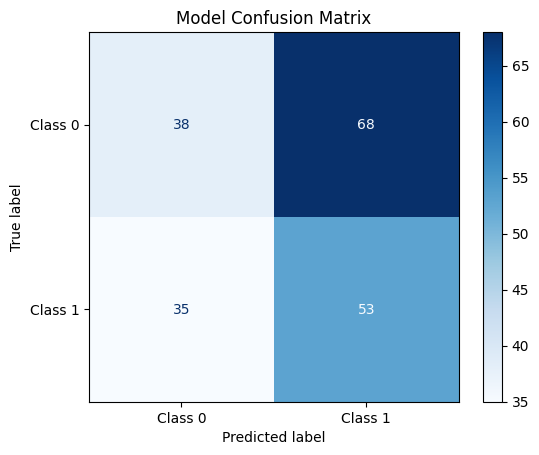

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(loader, model):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in loader:
            output = model(batch).view(-1)
            # Apply sigmoid and threshold
            preds = (torch.sigmoid(output) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch.y.cpu().numpy())
            
    # FORCE 2x2 MATRIX: The 'labels' argument prevents the FixedLocator error
    cm = confusion_matrix(all_targets, all_preds, labels=[0, 1])
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(cmap='Blues')
    plt.title("Model Confusion Matrix")
    plt.show()

plot_confusion_matrix(test_loader, model)

[<a href="#content">Back to top</a>]